In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


import nvitk as nv
from nvitk import db

In [2]:
repo, xnat_config = db.get_repo_from_settings(return_xnat_config=True)

Using local root: ~/nvitk/dataset/nvitk-dataset


DATAPREP

In [6]:
aux = repo.image(modality='4dflow', variables=['flow_mean'], wide=False)
aux = aux[(aux['variable_id' ] == 'flow_mean') & (aux['value_num'].notna())]

_STATSMODELS_BASE_DIR = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/nvitk-statmodels/')

_SUBJECTS = pd.unique(aux.subject_uid)
_CLINICAL_VARS = ['age_at_mri', 'apoe_group', 'apoe', 'bmi', 'pp', 'map', 'hematocrit', 'pedframi10', 'pedframi30', 'sex', 'score2', 'tacsctot_group']
_PLAQUE_VARS = ['total_carotid_plaque_vol', 'total_femoral_plaque_vol', 'total_plaque_vol', 'right_carotid_plaque_vol', 'left_carotid_plaque_vol']
_COGNITIVE_VARS = ['z_compo_processingspeed', 'z_compo_globalfull', 'z_compo_epismemory', 'z_compo_attworkmemospeed']
_FLOW_VARS = ['flow_mean', 'pi']
_ASL_VARS = ['mean_cbf', 'att_mean']

TERRITORY_FLOW_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": ( "left_aca", "right_aca"),
    "MCA": ("left_mca", "right_mca"),
    "PCA": ("left_pca", "right_pca"),
    "Basilar": ("basilar",),
    # "ICA-WS": ("left_ica", "right_ica"),
    # "ICA-WB": ("left_ica", "right_ica"),
    # "Venous-WB": ("sagital_sinus", "straight_sinus", "left_transverse", "right_transverse"),
}

TERRITORY_ASL_V8_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": (
        "left_aca_8",
        "right_aca_8",
    ),
    "MCA": (
        "left_mca_8",
        "right_mca_8",
    ),
    "PCA": (
        "left_pca_8",
        "right_pca_8",
    ),
    "Basilar": (
        "left_basilar_8",
        "right_basilar_8",
    ),
    # "ICA-WS": ("watershed_0", "watershed_8"),
    # "ICA-WB": ("ctx_whole_brain",),
    # "Venous-WB": ("ctx_whole_brain",),
}

In [7]:
clinical  = repo.clinical(variables=_CLINICAL_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
plaque    = repo.clinical(variables=_PLAQUE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
cognitive = repo.cognitive(variables=_COGNITIVE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
clinical   = repo.join([clinical, plaque, cognitive])

flow      = repo.image(modality='4dflow', variables=_FLOW_VARS, filters={'subject_uid': {'$in': _SUBJECTS}}, pipeline='v1')
asl       = repo.image(modality='asl', variables=_ASL_VARS, atlas='vascular-8', filters={'subject_uid': {'$in': _SUBJECTS}})
asl_wb    = repo.image(
    modality='asl', variables=_ASL_VARS, atlas='desikan', 
    regions=['ctx-whole-brain'],
    filters={'subject_uid': {'$in': _SUBJECTS}}
    )
image_df  = repo.join([flow, asl, asl_wb])

territory_df = nv.stats.melt_imaging_territories(
    image_df, id_cols=['subject_uid'], 
    flow_vars=_FLOW_VARS, asl_vars=_ASL_VARS, 
    territory_flow_regions=TERRITORY_FLOW_REGIONS,
    territory_asl_v8_regions=TERRITORY_ASL_V8_REGIONS,
    include_frame_index=False
)

In [8]:
_COVAR_FOR_MODEL = [
    "tacsctot_group",
    "age_at_mri",
    "sex",
    "hematocrit",
    "score2",
    "pp",
    "map"
]
_cov = [c for c in _COVAR_FOR_MODEL if c in clinical.columns]

# Explicit flow vs ASL region lists per analysis territory (same ASL region can
# pair with different flow groups, e.g. ctx-whole-brain for ICA-WB and Venous-WB).
TERRITORY_DEFINITIONS = {
    name: {"flow": TERRITORY_FLOW_REGIONS[name], "asl": TERRITORY_ASL_V8_REGIONS[name]}
    for name in TERRITORY_FLOW_REGIONS
}
analysis_df = nv.stats.build_analysis_df_from_territory_definitions(
    image_df,
    clinical,
    TERRITORY_DEFINITIONS,
    flow_vars=_FLOW_VARS,
    asl_vars=_ASL_VARS,
    covariate_cols=_cov,
)

analysis_df = analysis_df.dropna().reset_index(drop=True)
analysis_df["age_c"] = analysis_df["age_at_mri"] - float(analysis_df["age_at_mri"].mean())
analysis_df = analysis_df.drop(columns=['age_at_mri'])
analysis_df['territory'] = pd.Categorical(analysis_df['territory'], categories=list(TERRITORY_ASL_V8_REGIONS.keys()), ordered=True)
analysis_df['tacsctot_group'] = pd.Categorical(analysis_df['tacsctot_group'], categories=['g0', 'g1', 'g2', 'g3'], ordered=True)
analysis_df['mean_cbf'] = analysis_df['mean_cbf'].astype(np.float32)
analysis_df['hematocrit'] = analysis_df['hematocrit'].astype(np.float32)
analysis_df['score2'] = analysis_df['score2'].astype(np.float32)
analysis_df['pp'] = analysis_df['pp'].astype(np.float32)
analysis_df['age_c'] = analysis_df['age_c'].astype(np.float32)
analysis_df

,subject_uid,territory,flow_mean,pi,mean_cbf,att_mean,tacsctot_group,sex,hematocrit,score2,pp,map,age_c
0,PESA1006009,ACA,146.617585,0.722523,58.483761,1.280129,g0,1,47.0,4.625464,49.0,91.333333,5.082217
1,PESA10061584,ACA,58.467905,0.837771,40.072781,1.305152,g2,1,48.0,5.979170,53.0,102.666667,6.482217
2,PESA10067929,ACA,113.204603,0.724601,59.831661,1.226889,g0,1,42.0,7.063850,62.0,106.666667,6.752217
3,PESA10086976,ACA,63.311970,0.608145,57.035610,1.221132,g0,0,45.0,1.596673,32.0,89.666667,-4.597783
4,PESA10112400,ACA,132.874938,0.613769,56.868347,1.232920,g0,1,48.0,3.986971,58.0,108.333333,-4.047783
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,PESA9897316,Basilar,178.221377,0.674136,45.512760,1.109104,g1,1,52.0,4.760891,39.0,81.0,-2.437783
1340,PESA9928801,Basilar,87.832792,0.567656,57.890354,1.080371,g0,0,45.0,2.783649,31.0,83.333333,4.342217
1341,PESA9935104,Basilar,245.827435,0.719752,39.562092,1.066424,g0,0,45.0,2.478144,46.0,91.333333,2.802217
1342,PESA9947716,Basilar,309.712580,0.857074,50.096241,1.116286,g1,1,42.0,3.722327,43.0,85.333333,1.342217


MEDIACIONES PI -> PP -> ATLL

Mixed Linear Model - att_mean
Formula: att_mean ~ pi + age_c + sex + hematocrit + score2
Observations: 2,018
territory groups: 6

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0372      0.0309  1.079e-246       ***
pi                                      0.0219      0.0093     0.01887         *
age_c                                   0.0026      0.0004    2.88e-11       ***
sex                                     0.0489      0.0038   6.192e-37       ***
hematocrit                              0.0035      0.0004   5.617e-18       ***
score2                                 -0.0029      0.0011     0.00738        **

territory random effects covariance
----------------------------------------------------------------------------------------
          Group
Group  0.003644

Variance components (subject_uid)
-------

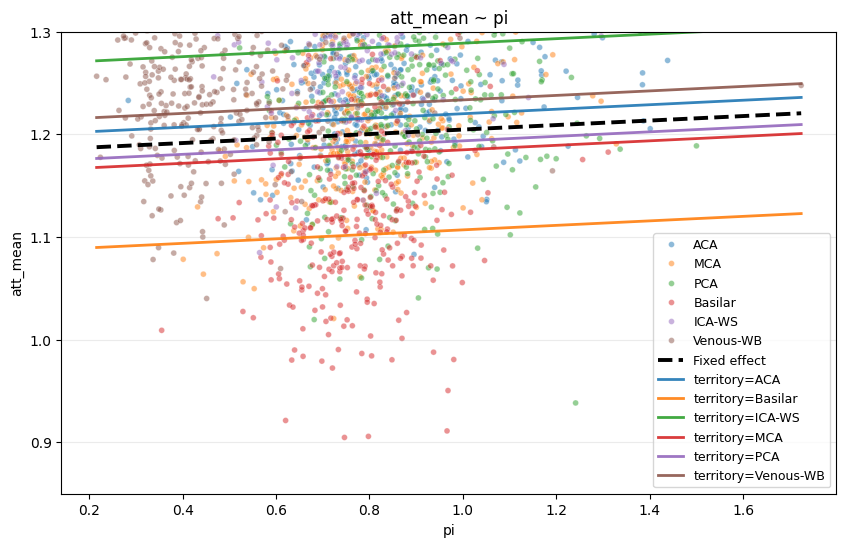

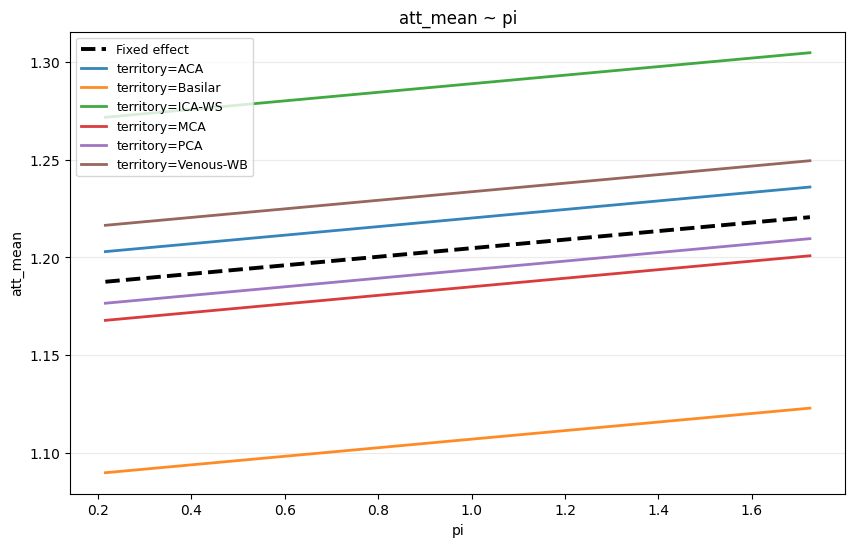

In [11]:
model_dir = 'mediations_pi_pp_att'
formula_o = (
    f"att_mean ~ pi + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pi",
    "att_mean",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_o,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=True,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean()), "score2": float(df_fit["score2"].mean())},
)
fig.axes[0].set_ylim(0.85, 1.3)

fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean()), "score2": float(df_fit["score2"].mean())},
)

PI -> PP

Mixed Linear Model - pp
Formula: pp ~ pi + age_c + sex + hematocrit + score2
Observations: 2,018
territory groups: 6

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                              37.8619      2.5553   1.139e-49       ***
pi                                     11.0885      1.2053   3.581e-20       ***
age_c                                  -0.3185      0.0524   1.219e-09       ***
sex                                     2.4544      0.5109   1.556e-06       ***
hematocrit                             -0.2599      0.0535   1.206e-06       ***
score2                                  2.7170      0.1412   1.818e-82       ***

territory random effects covariance
----------------------------------------------------------------------------------------
          Group
Group  2.610635

Variance components (subject_uid)
-------------------

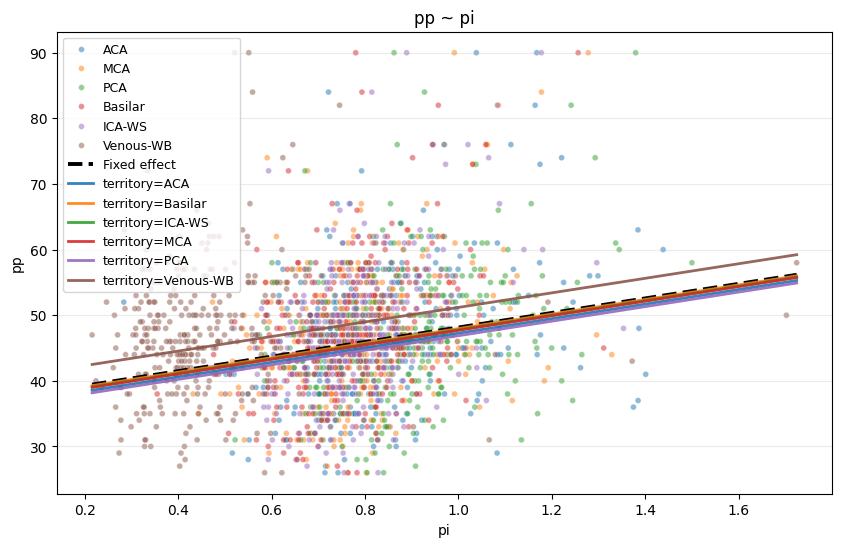

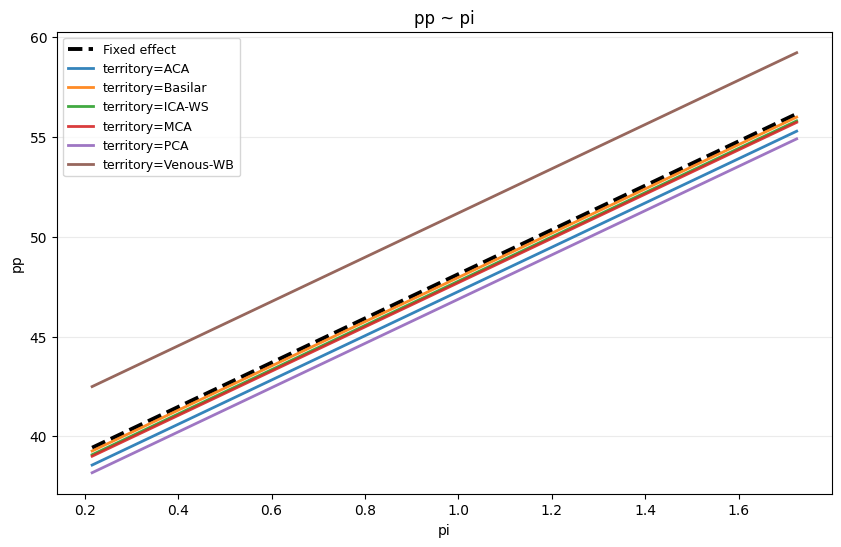

In [8]:
model_dir = 'mediations_pi_pp_att'
formula_m = (
    f"pp ~ pi + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "pi",
    "att_mean",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res_mediator, df_fit_mediator, _meta_mediator = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_m,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res_mediator,
    outcome_name="pp",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res_mediator,
    df_fit=df_fit_mediator,
    x="pi",
    y="pp",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="pp ~ pi",
    x_label="pi",
    y_label="pp",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_mediator["hematocrit"].mean()), "age_c": float(df_fit_mediator["age_c"].mean()), "score2": float(df_fit_mediator["score2"].mean())},
)

# fig.axes[0].set_ylim(30, 60)

fig = nv.stats.plot_mixedlm_params(
    result=res_mediator,
    df_fit=df_fit_mediator,
    x="pi",
    y="pp",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="pp ~ pi",
    x_label="pi",
    y_label="pp",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_mediator["hematocrit"].mean()), "age_c": float(df_fit_mediator["age_c"].mean()), "score2": float(df_fit_mediator["score2"].mean())},
)

PP -> ATT

Mixed Linear Model - att_mean
Formula: att_mean ~ pp + pi + age_c + sex + hematocrit + score2
Observations: 2,018
territory groups: 6

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0663      0.0316  4.417e-250       ***
pp                                     -0.0008      0.0002   3.161e-06       ***
pi                                      0.0310      0.0095    0.001064        **
age_c                                   0.0024      0.0004    2.13e-09       ***
sex                                     0.0508      0.0039   1.045e-39       ***
hematocrit                              0.0033      0.0004   4.162e-16       ***
score2                                 -0.0007      0.0012      0.5231        NS

territory random effects covariance
-----------------------------------------------------------------------------

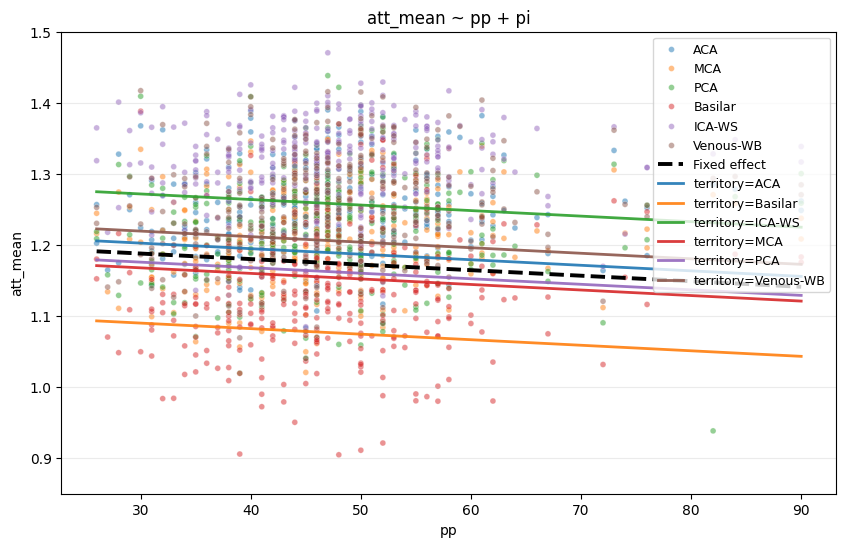

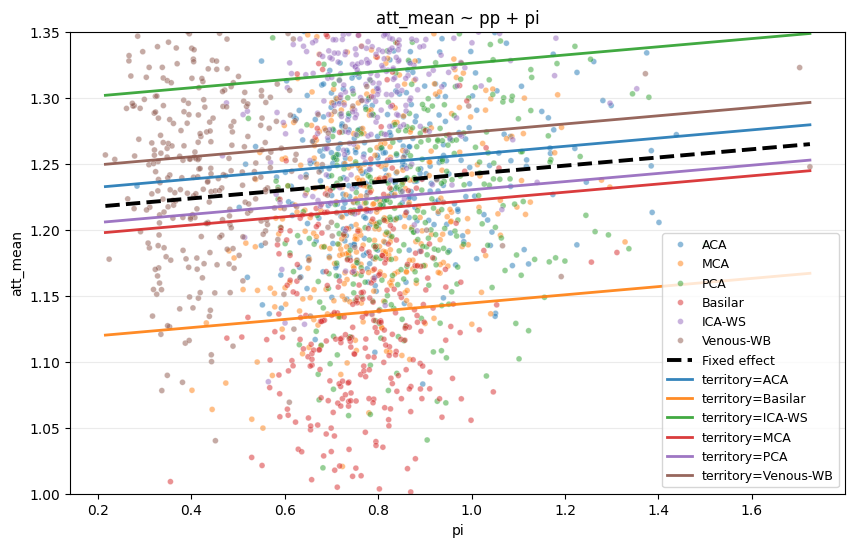

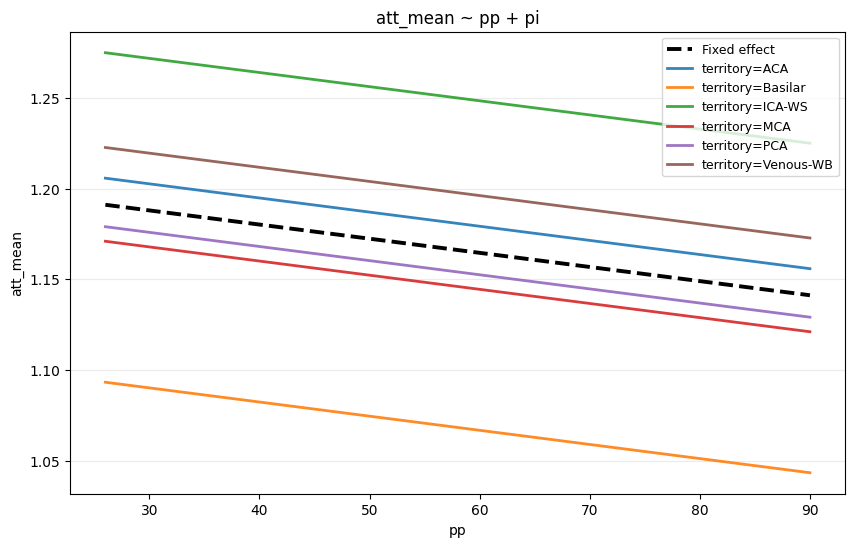

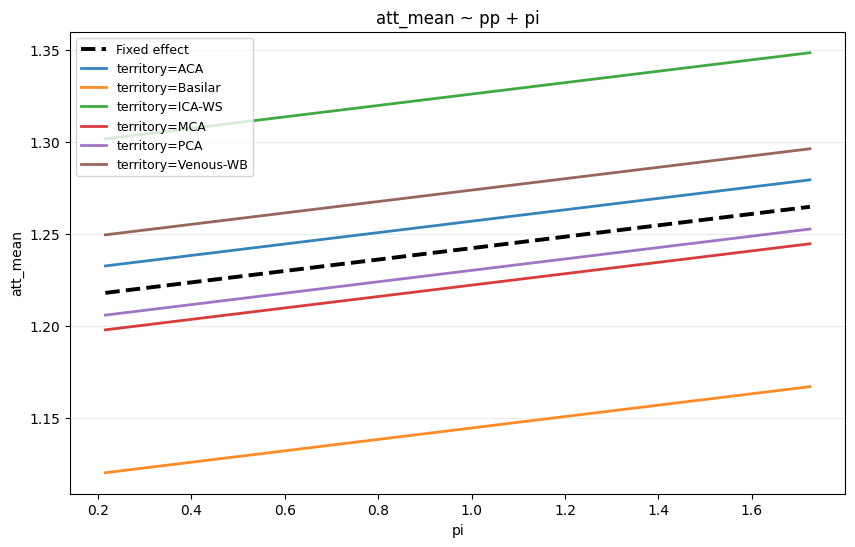

In [10]:
model_dir = 'mediations_pi_pp_att'
formula_o = (
    f"att_mean ~ pp + pi + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "pi",
    "att_mean",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res_outcome, df_fit_outcome, _meta_outcome = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_o,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=True,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res_outcome,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)
fig.axes[0].set_ylim(0.85, 1.5)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)
fig.axes[0].set_ylim(1, 1.35)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)


fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)


In [44]:
a_effect = res_mediator.params["pi"]
b_effect = res_outcome.params["pp"]
c_prime = res_outcome.params["pi"]

indirect_effect = a_effect * b_effect

print(f"a (pi → pp): {a_effect}")
print(f"b (pp → att): {b_effect}")
print(f"c' (pi → att | pp): {c_prime}")
print(f"Indirect effect (a*b): {indirect_effect}")

a (pi → pp): 11.08848376339373
b (pp → att): -0.0007795502061897179
c' (pi → att | pp): 0.031045908844621585
Indirect effect (a*b): -0.008644029804084921


Mixed Linear Model - att_mean
Formula: att_mean ~ pp + pi + pp:pi + age_c + sex + hematocrit + score2
Observations: 2,018
territory groups: 6

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0161      0.0447  2.034e-114       ***
pp                                      0.0002      0.0005      0.7444        NS
pi                                      0.0936      0.0328    0.004303        **
pp:pi                                  -0.0012      0.0006     0.04415         *
age_c                                   0.0024      0.0004   2.988e-09       ***
sex                                     0.0504      0.0039   4.956e-39       ***
hematocrit                              0.0033      0.0004    1.99e-16       ***
score2                                 -0.0007      0.0011      0.5432        NS

territory random effects

(0.9, 1.5)

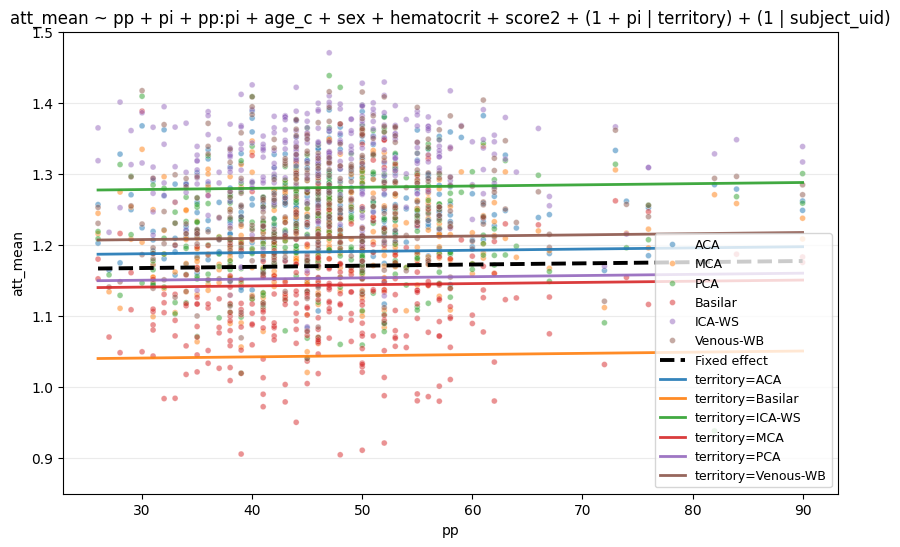

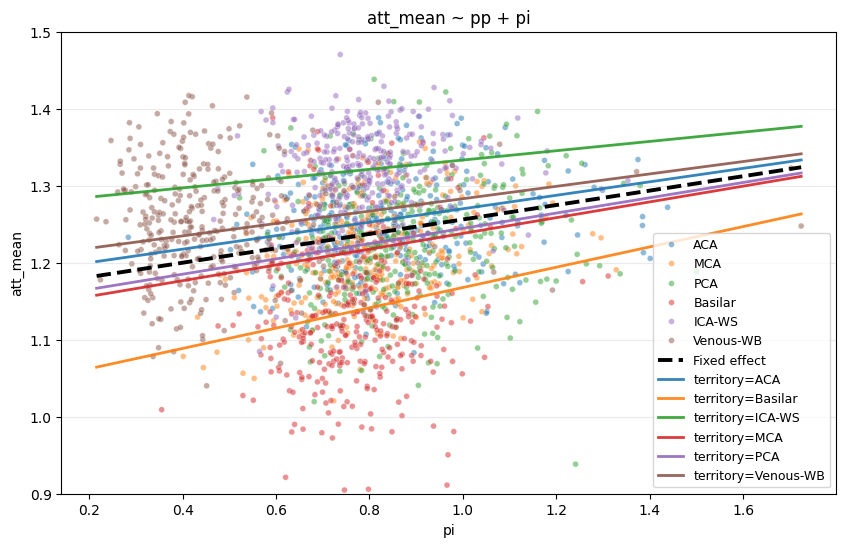

In [ ]:
model_dir = 'mediations_pi_pp_inter_att'
formula_o = (
    f"att_mean ~ pp + pi + pp:pi + age_c + sex + hematocrit + score2 + (1 + pi | territory) + (1 | subject_uid)"
)

_model_cols = [
    "pp",
    "pi",
    "att_mean",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res_outcome, df_fit_outcome, _meta_outcome = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_o,
    groups="territory",
    re_formula="1 + pi",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res_outcome,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi + pp:pi + age_c + sex + hematocrit + score2 + (1 + pi | territory) + (1 | subject_uid)",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)
fig.axes[0].set_ylim(0.85, 1.5)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pi",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pi",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)
fig.axes[0].set_ylim(.9, 1.5)

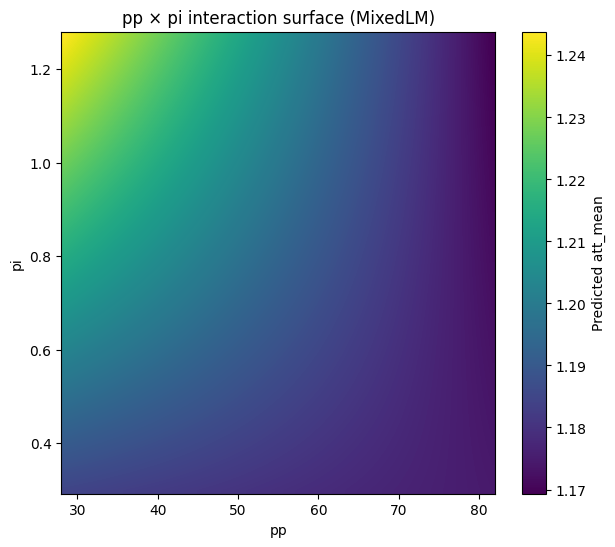

In [49]:

import matplotlib.pyplot as plt

def plot_pp_pi_surface(model, df, n=60, covariate_refs=None):
    pp_grid = np.linspace(df["pp"].quantile(0.01), df["pp"].quantile(0.99), n)
    pi_grid = np.linspace(df["pi"].quantile(0.01), df["pi"].quantile(0.99), n)

    grid = pd.DataFrame([
        (pp, pi) for pp in pp_grid for pi in pi_grid
    ], columns=["pp", "pi"])

    # covariates fijas (igual que tu plotting function)
    covariate_refs = covariate_refs or {}
    for k, v in covariate_refs.items():
        grid[k] = v

    p = model.params

    # efectos fijos (MixedLM no incluye intercept automático en params siempre explícito)
    grid["pred"] = (
        p["Intercept"]
        + p["pp"] * grid["pp"]
        + p["pi"] * grid["pi"]
        + p.get("pp:pi", 0.0) * grid["pp"] * grid["pi"]
        + sum(p[k] * grid[k] for k in covariate_refs.keys())
    )

    Z = grid.pivot(index="pi", columns="pp", values="pred")

    plt.figure(figsize=(7, 6))
    plt.imshow(
        Z.values,
        origin="lower",
        aspect="auto",
        extent=[pp_grid.min(), pp_grid.max(), pi_grid.min(), pi_grid.max()],
        interpolation="bilinear"
    )
    plt.colorbar(label="Predicted att_mean")
    plt.xlabel("pp")
    plt.ylabel("pi")
    plt.title("pp × pi interaction surface (MixedLM)")
    plt.show()

plot_pp_pi_surface(res_outcome, df_fit_outcome, covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())})

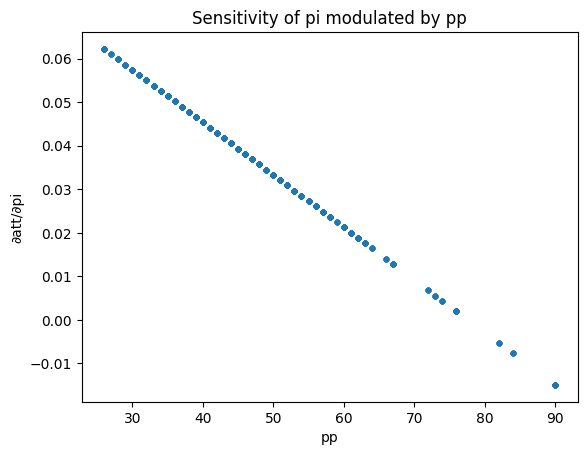

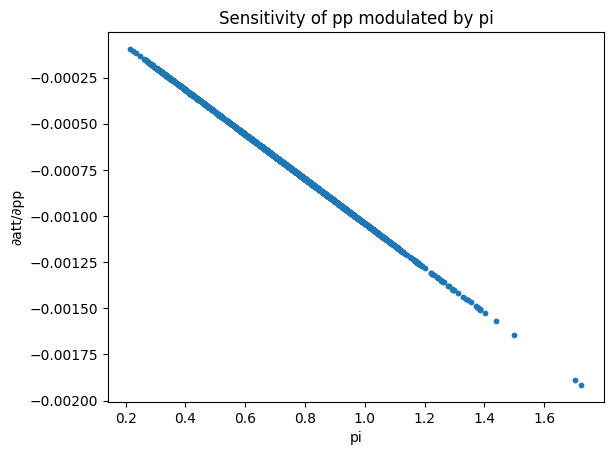

In [50]:
def compute_marginal_slopes(model, df):
    p = model.params

    interaction = p.get("pp:pi", 0.0)

    df = df.copy()

    df["d_att_d_pi_given_pp"] = p["pi"] + interaction * df["pp"]
    df["d_att_d_pp_given_pi"] = p["pp"] + interaction * df["pi"]

    return df

def plot_gradients(df):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.scatter(df["pp"], df["d_att_d_pi_given_pp"], s=10)
    plt.xlabel("pp")
    plt.ylabel("∂att/∂pi")
    plt.title("Sensitivity of pi modulated by pp")
    plt.show()

    plt.figure()
    plt.scatter(df["pi"], df["d_att_d_pp_given_pi"], s=10)
    plt.xlabel("pi")
    plt.ylabel("∂att/∂pp")
    plt.title("Sensitivity of pp modulated by pi")
    plt.show()

df_with_gradients = compute_marginal_slopes(res_outcome, analysis_df)
plot_gradients(df_with_gradients)


In [51]:
def territory_specific_effects(model, df):
    p = model.params

    df = df.copy()

    # fixed part
    fixed = (
        p["Intercept"]
        + p["pp"] * df["pp"]
        + p["pi"] * df["pi"]
        + p.get("pp:pi", 0.0) * df["pp"] * df["pi"]
    )

    # random effects
    re = model.random_effects

    df["pred_fixed"] = fixed

    # territory intercept + slope(pi)
    df["pred_random"] = 0.0

    for t in df["territory"].unique():
        if t in re:
            b0 = re[t].get("Group", 0.0)
            b1 = re[t].get("pi", 0.0)

            mask = df["territory"] == t
            df.loc[mask, "pred_random"] = b0 + b1 * df.loc[mask, "pi"]

    df["pred_total"] = df["pred_fixed"] + df["pred_random"]

    return df

df_with_territory_effects = territory_specific_effects(res_outcome, analysis_df)
df_with_territory_effects

,subject_uid,territory,flow_mean,pi,mean_cbf,att_mean,tacsctot_group,sex,hematocrit,score2,pp,map,age_c,pred_fixed,pred_random,pred_total
0,PESA1006009,ACA,146.617585,0.722523,58.483761,1.280129,g0,1,47.0,4.625464,49.0,91.333333,5.07947,1.049083,0.015623,1.064706
1,PESA10061584,ACA,58.467905,0.837771,40.072781,1.305152,g2,1,48.0,5.979170,53.0,102.666667,6.47947,1.049678,0.014912,1.064590
2,PESA10067929,ACA,113.204603,0.724601,59.831661,1.226889,g0,1,42.0,7.063850,62.0,106.666667,6.74947,1.039938,0.015610,1.055549
3,PESA10086976,ACA,63.311970,0.608145,57.035610,1.221132,g0,0,45.0,1.596673,32.0,89.666667,-4.60053,1.054800,0.016328,1.071128
4,PESA10112400,ACA,132.874938,0.613769,56.868347,1.232920,g0,1,48.0,3.986971,58.0,108.333333,-4.05053,1.040153,0.016294,1.056447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,PESA9897316,Venous-WB,238.016415,0.278454,61.322540,1.255851,g1,1,52.0,4.760891,39.0,81.0,-2.44053,1.035467,0.036419,1.071886
2014,PESA9928801,Venous-WB,30.023411,1.066115,64.188530,1.187852,g0,0,45.0,2.783649,31.0,83.333333,4.33947,1.081115,0.026071,1.107186
2015,PESA9935104,Venous-WB,185.321042,0.394184,56.903358,1.171528,g0,0,45.0,2.478144,46.0,91.333333,2.79947,1.038684,0.034899,1.073583
2016,PESA9947716,Venous-WB,302.607926,0.407565,72.428658,1.258868,g1,1,42.0,3.722327,43.0,85.333333,1.33947,1.040174,0.034723,1.074897


Bootrstrap

In [29]:
def bootstrap_mediation_by_subject(
    df,
    formula_m,
    formula_y,
    model_cols,
    n_boot=500,
    seed=42,
):
    """
    Mediation bootstrap (a*b) resampling at the subject level.

    Returns:
        dict with:
            - indirect_dist (np.array)
            - ci_low, ci_high
            - mean
            - p_value (two-sided bootstrap)
       
    """
    rng = np.random.default_rng(seed)
    subjects = df["subject_uid"].unique()

    indirects = []

    for _ in range(n_boot):
        # ---- bootstrap per subject ----
        sampled_subjects = rng.choice(subjects, size=len(subjects), replace=True)

        dfs = []
        for i, subj in enumerate(sampled_subjects):
            df_sub = df[df["subject_uid"] == subj].copy()

            # reindexing key for mixed models
            df_sub["subject_uid"] = f"{subj}_boot{i}"
            dfs.append(df_sub)

        df_boot = pd.concat(dfs, ignore_index=True)

        try:
            # ---- mediator model (a) ----
            res_m, _, _ = nv.stats.fit_or_load_mixedlm(
                model_path=None,
                data=df_boot,
                formula=formula_m,
                groups="territory",
                re_formula="1",
                vc_formula={"subject": "0 + C(subject_uid)"},
                overwrite=True,
                required_columns=model_cols,
            )

            # ---- outcome model (b, c') ----
            res_y, _, _ = nv.stats.fit_or_load_mixedlm(
                model_path=None,
                data=df_boot,
                formula=formula_y,
                groups="territory",
                re_formula="1",
                vc_formula={"subject": "0 + C(subject_uid)"},
                overwrite=True,
                required_columns=model_cols,
            )

            a = res_m.params["pi"]
            b = res_y.params["pp"]

            indirects.append(a * b)

        except Exception as e:
            import traceback
            traceback.print_exc()
            continue  

    indirects = np.array(indirects)

    # ---- summary ----
    ci_low = np.percentile(indirects, 2.5)
    ci_high = np.percentile(indirects, 97.5)
    mean = indirects.mean()

    # two-sided bootstrap p-value
    p_value = 2 * min(
        (indirects <= 0).mean(),
        (indirects >= 0).mean()
    )

    return {
        "indirect_dist": indirects,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "mean": mean,
        "p_value": p_value,
    }

res_boot = bootstrap_mediation_by_subject(
    df=analysis_df,
    formula_m="pp ~ pi + age_c + sex + hematocrit + score2",
    formula_y="att_mean ~ pp + pi + age_c + sex + hematocrit + score2",
    model_cols=_model_cols,
    n_boot=50,
)

print(res_boot)

KeyboardInterrupt: 

Mixed Linear Model - att_mean
Formula: att_mean ~ pp + age_c + sex + hematocrit + score2
Observations: 2,357
territory groups: 7

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               1.0827      0.0271           0       ***
pp                                     -0.0006      0.0002   3.098e-05       ***
age_c                                   0.0028      0.0004   1.126e-15       ***
sex                                     0.0527      0.0035   1.495e-50       ***
hematocrit                              0.0034      0.0004    1.06e-19       ***
score2                                 -0.0012      0.0011      0.2685        NS

territory random effects covariance
----------------------------------------------------------------------------------------
          Group
Group  0.003064

Variance components (subject_uid)
-------

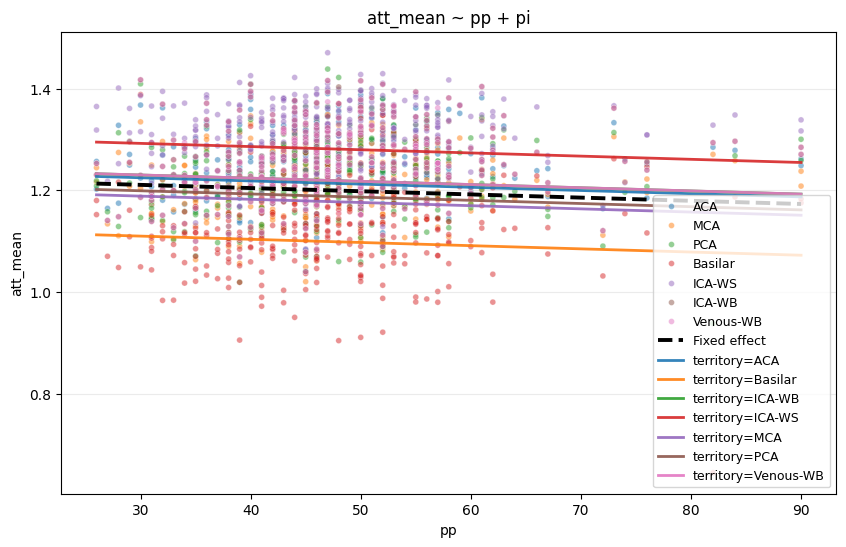

In [ ]:
model_dir = 'mediations_pp_att'
formula_o = (
    f"att_mean ~ pp + age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pp",
    "att_mean",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2"
]

res_outcome, df_fit_outcome, _meta_outcome = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula_o,
    groups="territory",
    re_formula="1",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res_outcome,
    outcome_name="att_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res_outcome,
    df_fit=df_fit_outcome,
    x="pp",
    y="att_mean",
    group="territory",
    errorbar=True,
    mode="auto",
    hue="territory",
    include_points=True,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="att_mean ~ pp + pi",
    x_label="pp",
    y_label="att_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit_outcome["hematocrit"].mean()), "age_c": float(df_fit_outcome["age_c"].mean()), "score2": float(df_fit_outcome["score2"].mean())},
)

In [ ]:
import matplotlib.pyplot as plt

plt.hist(boot_dist, bins=50)
plt.axvline(ci_low)
plt.axvline(ci_high)
plt.title("Bootstrap indirect effect (a*b)")
plt.xlabel("Effect size")
plt.ylabel("Frequency")

plt.savefig(_STATSMODELS_BASE_DIR / model_dir / "bootstrap_indirect.png")
plt.close()

CACS

Mixed Linear Model - mean_cbf
Formula: mean_cbf ~ C(tacsctot_group, Treatment('g0')) * C(territory, Treatment('MCA')) + age_c + sex + hematocrit + score2
Observations: 2,357
territory groups: 7

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                             101.2304      2.1934           0       ***
C(tacsctot_group, Treatment('g0'))[T.g1]      1.7884      1.0091     0.07635         .
C(tacsctot_group, Treatment('g0'))[T.g2]      1.0922      1.5643      0.4851        NS
C(tacsctot_group, Treatment('g0'))[T.g3]     -3.6571      2.1067     0.08258         .
C(territory, Treatment('MCA'))[T.ACA]     -0.2763      0.8116      0.7335        NS
C(territory, Treatment('MCA'))[T.PCA]     -5.0674      0.8116   4.264e-10       ***
C(territory, Treatment('MCA'))[T.Basilar]     -4.4389      0.8158   5.292e-08       ***
C(territory, Treatment(

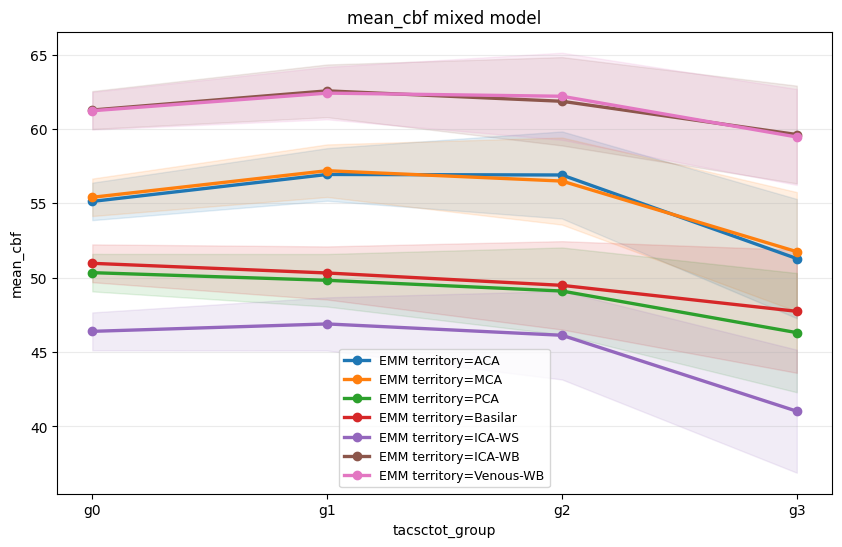

In [29]:
model_dir = 'cacs_mean_cbf'
formula = (
    f"mean_cbf ~ C(tacsctot_group, Treatment('g0')) "
    f"* C(territory, Treatment('MCA')) "
    f"+ age_c + sex + hematocrit + score2"
)

_model_cols = [
    "mean_cbf",
    "tacsctot_group",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2",
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula,
    groups="territory",
    re_formula="0",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=True,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="mean_cbf",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="tacsctot_group",
    y="mean_cbf",
    group="territory",
    errorbar=True,
    categorical_order=["g0", "g1", "g2", "g3"],
    mode="categorical",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="mean_cbf mixed model",
    x_label="tacsctot_group",
    y_label="mean_cbf",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean()), "score2": float(df_fit["score2"].mean())},
)

Mixed Linear Model - pi
Formula: pi ~ C(tacsctot_group, Treatment('g0')) * C(territory, Treatment('MCA')) + age_c + sex + hematocrit + score2
Observations: 2,357
territory groups: 7

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                               0.8044      0.0381   3.751e-99       ***
C(tacsctot_group, Treatment('g0'))[T.g1]      0.0328      0.0175     0.06127         .
C(tacsctot_group, Treatment('g0'))[T.g2]      0.0396      0.0271      0.1449        NS
C(tacsctot_group, Treatment('g0'))[T.g3]      0.0013      0.0366      0.9711        NS
C(territory, Treatment('MCA'))[T.ACA]      0.0525      0.0141   0.0001951       ***
C(territory, Treatment('MCA'))[T.PCA]      0.0987      0.0141     2.4e-12       ***
C(territory, Treatment('MCA'))[T.Basilar]     -0.0109      0.0142      0.4414        NS
C(territory, Treatment('MCA'))[T.IC

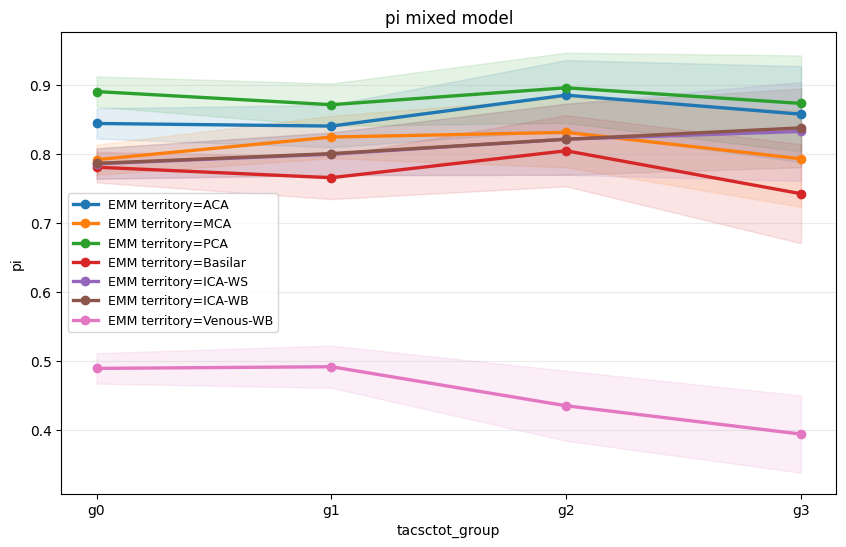

In [ ]:
model_dir = 'cacs_pi'
formula = (
    f"pi ~ C(tacsctot_group, Treatment('g0')) "
    f"* C(territory, Treatment('MCA')) "
    f"+ age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pi",
    "tacsctot_group",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2",
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula,
    groups="territory",
    re_formula="0",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=False,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="pi",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="tacsctot_group",
    y="pi",
    group="territory",
    errorbar=True,
    categorical_order=["g0", "g1", "g2", "g3"],
    mode="categorical",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="pi mixed model",
    x_label="tacsctot_group",
    y_label="pi",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean()), "score2": float(df_fit["score2"].mean())},
)

Mixed Linear Model - flow_mean
Formula: flow_mean ~ C(tacsctot_group, Treatment('g0')) * C(territory, Treatment('MCA')) + age_c + sex + hematocrit + score2
Observations: 2,357
territory groups: 7

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                             285.7804     14.3695    5.17e-88       ***
C(tacsctot_group, Treatment('g0'))[T.g1]      0.6261      6.6108      0.9245        NS
C(tacsctot_group, Treatment('g0'))[T.g2]     -1.8815     10.2476      0.8543        NS
C(tacsctot_group, Treatment('g0'))[T.g3]     -7.8105     13.8014      0.5714        NS
C(territory, Treatment('MCA'))[T.ACA]    -69.2733      5.3166   8.293e-39       ***
C(territory, Treatment('MCA'))[T.PCA]    -98.0319      5.3166   6.398e-76       ***
C(territory, Treatment('MCA'))[T.Basilar]      7.1499      5.3444      0.1809        NS
C(territory, Treatmen

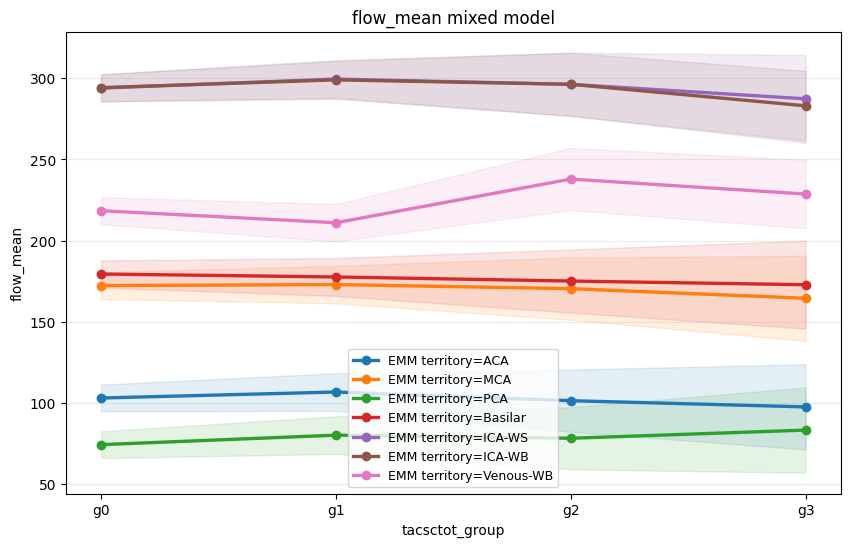

In [27]:
model_dir = 'cacs_flow_mean'
formula = (
    f"flow_mean ~ C(tacsctot_group, Treatment('g0')) "
    f"* C(territory, Treatment('MCA')) "
    f"+ age_c + sex + hematocrit + score2"
)

_model_cols = [
    "pi",
    "tacsctot_group",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2",
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula,
    groups="territory",
    re_formula="0",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=True,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="flow_mean",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="tacsctot_group",
    y="flow_mean",
    group="territory",
    errorbar=True,
    categorical_order=["g0", "g1", "g2", "g3"],
    mode="categorical",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="flow_mean mixed model",
    x_label="tacsctot_group",
    y_label="flow_mean",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean()), "score2": float(df_fit["score2"].mean())},
)

Mixed Linear Model - pp
Formula: pp ~ C(tacsctot_group, Treatment('g0')) * C(territory, Treatment('MCA')) + age_c + sex + hematocrit + score2
Observations: 2,357
territory groups: 7

Fixed effects
----------------------------------------------------------------------------------------
Parameter                                 Coef     Std.Err     P-value       Sig
Intercept                              45.3726      2.2214   1.003e-92       ***
C(tacsctot_group, Treatment('g0'))[T.g1]      0.7353      1.0220      0.4718        NS
C(tacsctot_group, Treatment('g0'))[T.g2]      3.9252      1.5842     0.01322         *
C(tacsctot_group, Treatment('g0'))[T.g3]      2.0817      2.1336      0.3292        NS
C(territory, Treatment('MCA'))[T.ACA]     -0.0000      0.8219           1        NS
C(territory, Treatment('MCA'))[T.PCA]     -0.0000      0.8219           1        NS
C(territory, Treatment('MCA'))[T.Basilar]      0.0167      0.8262      0.9839        NS
C(territory, Treatment('MCA'))[T.IC

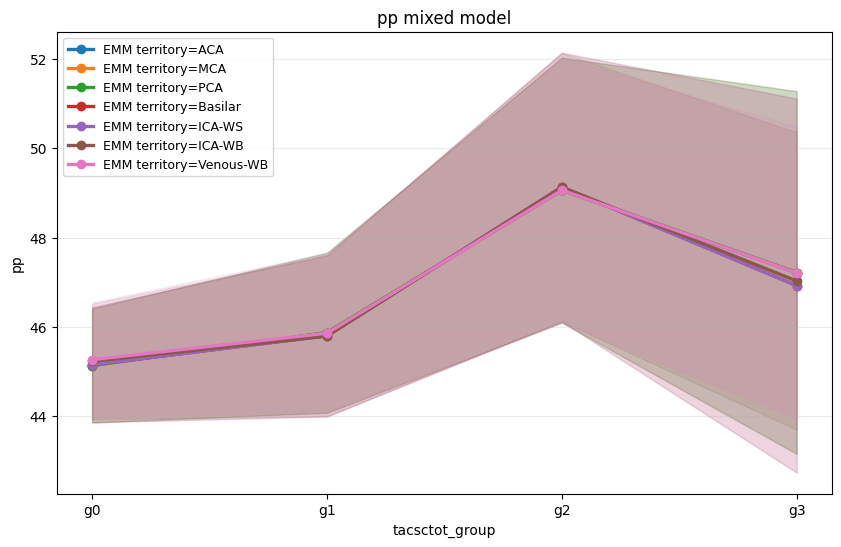

In [ ]:
model_dir = 'cacs_pp'
formula = (
    f"pp ~ C(tacsctot_group, Treatment('g0')) "
    f"* C(territory, Treatment('MCA')) "
    f"+ age_c + sex + hematocrit"
)

_model_cols = [
    "pp",
    "tacsctot_group",
    "territory",
    "age_c",
    "sex",
    "hematocrit",
    "subject_uid",
    "score2",
]

res, df_fit, _meta = nv.stats.fit_or_load_mixedlm(
    model_path=_STATSMODELS_BASE_DIR / model_dir / "model.pkl",
    data=analysis_df,
    formula=formula,
    groups="territory",
    re_formula="0",
    vc_formula={"subject": "0 + C(subject_uid)"},
    overwrite=True,
    required_columns=_model_cols,
)

nv.stats.print_mixedlm_info(
    res,
    outcome_name="pp",
    group_name="territory",
    vc_group_name="subject_uid",
    output_path=_STATSMODELS_BASE_DIR / model_dir / "info.txt",
)

fig = nv.stats.plot_mixedlm_params(
    result=res,
    df_fit=df_fit,
    x="tacsctot_group",
    y="pp",
    group="territory",
    errorbar=True,
    categorical_order=["g0", "g1", "g2", "g3"],
    mode="categorical",
    hue="territory",
    include_points=False,
    output_path=_STATSMODELS_BASE_DIR / model_dir / "plot.png",
    title="pp mixed model",
    x_label="tacsctot_group",
    y_label="pp",
    covariate_refs={"sex": 0.0, "hematocrit": float(df_fit["hematocrit"].mean()), "age_c": float(df_fit["age_c"].mean())},
)